<a href="https://colab.research.google.com/github/RishabhYadav7740/fraud-prediction-model/blob/main/Fraud_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

import joblib

In [ ]:
df = pd.read_csv("Fraud Detection Dataset.csv")

df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [ ]:
print("Dataset shape:", df.shape)

memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print("Memory usage:", round(memory_mb, 2), "MB")

Dataset shape: (51000, 12)
Memory usage: 16.52 MB


In [ ]:
print(df.nunique().sort_values(ascending=False))

Transaction_ID                      50000
Transaction_Amount                  44821
User_ID                              4000
Account_Age                           119
Time_of_Transaction                    24
Number_of_Transactions_Last_24H        14
Location                                8
Transaction_Type                        5
Payment_Method                          5
Previous_Fraudulent_Transactions        5
Device_Used                             4
Fraudulent                              2
dtype: int64


In [ ]:
df = df.drop(columns=[
    "Transaction_ID",
    "User_ID"
])

In [ ]:
print("New dataset shape:", df.shape)

New dataset shape: (51000, 10)


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "Transaction_Type",
    "Time_of_Transaction",
    "Device_Used",
    "Location",
    "Payment_Method"
]

label_encoders = {}

for col in categorical_columns:

    df[col] = df[col].fillna("Unknown").astype(str)

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

print("Encoding done")

Encoding done


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Fraudulent", axis=1)
y = df["Fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)

Train shape: (40800, 9)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
print("Missing values in each column:")
print(X_train.isnull().sum())

Missing values in each column:
Transaction_Amount                  2036
Transaction_Type                       0
Time_of_Transaction                    0
Device_Used                            0
Location                               0
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                         0
dtype: int64


In [ ]:
# Fill missing values using median
X_train["Transaction_Amount"].fillna(
    X_train["Transaction_Amount"].median(),
    inplace=True
)

X_test["Transaction_Amount"].fillna(
    X_train["Transaction_Amount"].median(),
    inplace=True
)

/tmp/ipykernel_4855/347234280.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["Transaction_Amount"].fillna(
/tmp/ipykernel_4855/347234280.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

In [ ]:
print("Remaining missing values:")
print(X_train.isnull().sum())

Remaining missing values:
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42
)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE applied successfully")

SMOTE applied successfully


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                48480 non-null  float64
 1   Transaction_Type                  51000 non-null  int64  
 2   Time_of_Transaction               51000 non-null  int64  
 3   Device_Used                       51000 non-null  int64  
 4   Location                          51000 non-null  int64  
 5   Previous_Fraudulent_Transactions  51000 non-null  int64  
 6   Account_Age                       51000 non-null  int64  
 7   Number_of_Transactions_Last_24H   51000 non-null  int64  
 8   Payment_Method                    51000 non-null  int64  
 9   Fraudulent                        51000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 3.9 MB


In [ ]:
df.describe()

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,48480.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,2996.249784,1.994941,12.095353,1.182922,3.719549,1.995725,60.033902,7.495588,2.152020,0.049216
std,5043.932555,1.410956,7.265859,1.022680,2.445050,1.415150,34.384131,4.020080,1.648797,0.216320
min,5.030000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,1270.552500,1.000000,6.000000,0.000000,2.000000,1.000000,30.000000,4.000000,1.000000,0.000000
50%,2524.100000,2.000000,12.000000,1.000000,4.000000,2.000000,60.000000,7.000000,3.000000,0.000000
75%,3787.240000,3.000000,18.000000,2.000000,6.000000,3.000000,90.000000,11.000000,4.000000,0.000000
max,49997.800000,4.000000,24.000000,4.000000,8.000000,4.000000,119.000000,14.000000,5.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Transaction_Amount,2520
Transaction_Type,0
Time_of_Transaction,0
Device_Used,0
Location,0
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0
Payment_Method,0
Fraudulent,0


In [ ]:
# Check if any object (text) columns exist

object_columns = df.select_dtypes(include="object").columns

print("Object columns:", object_columns)

Object columns: Index([], dtype='object')


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [ ]:
feature_columns = X.columns

print(feature_columns)

Index(['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction',
       'Device_Used', 'Location', 'Previous_Fraudulent_Transactions',
       'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method'],
      dtype='object')


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:")

print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, y_pred))

Accuracy:
0.8919607843137255

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      9698
           1       0.06      0.08      0.07       502

    accuracy                           0.89     10200
   macro avg       0.50      0.51      0.50     10200
weighted avg       0.91      0.89      0.90     10200


Confusion Matrix:
[[9059  639]
 [ 463   39]]


In [ ]:
roc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.517600560841805


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                            Feature  Importance
0                Transaction_Amount    0.206220
6                       Account_Age    0.168740
2               Time_of_Transaction    0.126669
7   Number_of_Transactions_Last_24H    0.108384
4                          Location    0.092766
8                    Payment_Method    0.084579
5  Previous_Fraudulent_Transactions    0.081706
1                  Transaction_Type    0.074644
3                       Device_Used    0.056292


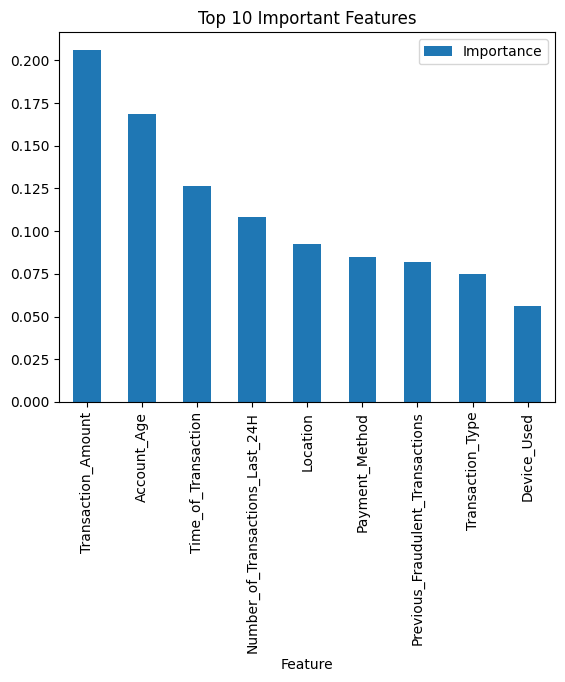

In [ ]:
feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
joblib.dump(
    model,
    "fraud_detection_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [ ]:
sample = X_test[0:1]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [ ]:
def predict_fraud(
    amount,
    account_age,
    transaction_type,
    time_of_transaction,
    device_used,
    location,
    payment_method,
    transactions_last_24h,
    previous_fraud_transactions
):

    import pandas as pd

    # Create input dictionary
    new_data = {
        "Transaction_Amount": amount,
        "Account_Age": account_age,
        "Transaction_Type": transaction_type,
        "Time_of_Transaction": time_of_transaction,
        "Device_Used": device_used,
        "Location": location,
        "Payment_Method": payment_method,
        "Number_of_Transactions_Last_24H": transactions_last_24h,
        "Previous_Fraudulent_Transactions": previous_fraud_transactions
    }

    # Convert to DataFrame
    new_df = pd.DataFrame([new_data])

    # Ensure correct column order
    new_df = new_df[feature_columns]

    # Apply same imputer
    new_df = imputer.transform(new_df)

    # Predict
    prediction = model.predict(new_df)[0]

    probability = model.predict_proba(new_df)[0][1]

    if prediction == 1:
        print("🚨 Fraudulent Transaction")
    else:
        print("✅ Legitimate Transaction")

    print("Fraud Probability:", round(probability, 3))

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# Fit on training data again
imputer.fit(X_train)

SimpleImputer(strategy='median')

In [ ]:
predict_fraud(
    amount=2500,
    account_age=24,
    transaction_type=1,
    time_of_transaction=12,
    device_used=2,
    location=3,
    payment_method=1,
    transactions_last_24h=5,
    previous_fraud_transactions=0
)

✅ Legitimate Transaction
Fraud Probability: 0.175


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
def predict_from_user():

    import pandas as pd

    print("\nEnter Transaction Details:\n")

    amount = float(input("Transaction Amount: "))
    account_age = int(input("Account Age: "))
    transaction_type = int(input("Transaction Type: "))
    time_of_transaction = int(input("Time of Transaction: "))
    device_used = int(input("Device Used: "))
    location = int(input("Location: "))
    payment_method = int(input("Payment Method: "))
    transactions_last_24h = int(input("Transactions in last 24 hours: "))
    previous_fraud_transactions = int(input("Previous Fraud Transactions: "))

    # Create input dictionary
    user_data = {
        "Transaction_Amount": amount,
        "Account_Age": account_age,
        "Transaction_Type": transaction_type,
        "Time_of_Transaction": time_of_transaction,
        "Device_Used": device_used,
        "Location": location,
        "Payment_Method": payment_method,
        "Number_of_Transactions_Last_24H": transactions_last_24h,
        "Previous_Fraudulent_Transactions": previous_fraud_transactions
    }

    # Convert to DataFrame
    new_df = pd.DataFrame([user_data])

    # Ensure correct column order
    new_df = new_df[feature_columns]

    # Apply imputer
    new_df = imputer.transform(new_df)

    # Predict
    prediction = model.predict(new_df)[0]

    probability = model.predict_proba(new_df)[0][1]

    print("\nResult:")

    if prediction == 1:
        print("🚨 Fraudulent Transaction")
    else:
        print("✅ Legitimate Transaction")

    print("Fraud Probability:", round(probability, 3))

In [ ]:
predict_from_user()


Enter Transaction Details:

Transaction Amount: 2000
Account Age: 2
Transaction Type: 2
Time of Transaction: 2
Device Used: 2
Location: 1
Payment Method: 1
Transactions in last 24 hours: 1
Previous Fraud Transactions: 1

Result:
✅ Legitimate Transaction
Fraud Probability: 0.15


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
